# Sonnet Generation with GPT-2

This notebook trains and evaluates the `SonnetGPT` model on Google Colab. It clones the repo, installs dependencies, runs training, and saves the generated sonnets.

## 1. Mount Google Drive & Clone Repo

In [1]:
import os

REPO_URL = 'https://github.com/Lynx-Zhang/DD2424-Project.git'
REPO_DIR = '/content/DD2424-Project'
BRANCH = 'feat/sonnet-generation'

from google.colab import drive
drive.mount('/content/drive')

if not os.path.exists(REPO_DIR):
    !git clone -b {BRANCH} {REPO_URL} {REPO_DIR}
else:
    %cd {REPO_DIR}
    !git fetch --all
    !git checkout {BRANCH}
    !git pull origin {BRANCH}

%cd {REPO_DIR}

print("Current branch: ", end='')
!git branch --show-current

!mkdir -p predictions
!mkdir -p /content/drive/MyDrive/sonnet_checkpoints
!mkdir -p /content/drive/MyDrive/sonnet_logs

print("\nGPU info:")
!nvidia-smi -L

print("\nEnvironment ready!")

Mounted at /content/drive
Cloning into '/content/DD2424-Project'...
remote: Enumerating objects: 191, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 191 (delta 30), reused 20 (delta 20), pack-reused 137 (from 2)
Receiving objects: 100% (191/191), 32.78 MiB | 25.16 MiB/s, done.
Resolving deltas: 100% (89/89), done.
/content/DD2424-Project
Current branch: feat/sonnet-generation

GPU info:
GPU 0: NVIDIA L4 (UUID: GPU-c0d8022e-e8c3-7b10-4bc3-fbf58d2fabb6)

Environment ready!


## 2. Install Dependencies

In [2]:
!pip install -q \
    tqdm==4.58.0 \
    requests==2.25.1 \
    importlib-metadata==3.7.0 \
    filelock==3.0.12 \
    tokenizers==0.20 \
    explainaboard_client==0.0.7 \
    einops==0.8.0 \
    transformers==4.46.3 \
    sacrebleu==2.5.1 \
    scikit-learn

print("Dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 10.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 117.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

## 3. Verify Data Files

In [ ]:
!echo "Training sonnets:"
!wc -l data/sonnets.txt

!echo "\nHeld-out sonnets (test, first 3 lines only):"
!wc -l data/sonnets_held_out.txt

!echo "\nHeld-out dev sonnets (val prompts, first 3 lines):"
!wc -l data/sonnets_held_out_dev.txt

!echo "\nTrue held-out dev sonnets (val references):"
!wc -l data/TRUE_sonnets_held_out_dev.txt

## 4. Train — `gpt2` (small, fast baseline)

Trains with early stopping based on validation chrF score.  
The best checkpoint is saved to `best_<epochs>-<lr>-sonnet.pt`.

In [9]:
!python sonnet_generation.py \
    --use_gpu \
    --model_size gpt2 \
    --epochs 20 \
    --lr 1e-5 \
    --batch_size 8 \
    --patience 5 \
    --temperature 1.2 \
    --top_p 0.9 \
    --sonnet_out predictions/generated_sonnets_gpt2.txt

# Backup checkpoint and predictions to Drive
!cp best_20-1e-05-sonnet.pt /content/drive/MyDrive/sonnet_checkpoints/best_gpt2-$(date +%Y%m%d_%H%M%S).pt
!cp predictions/generated_sonnets_gpt2.txt /content/drive/MyDrive/sonnet_logs/generated_sonnets_gpt2-$(date +%Y%m%d_%H%M%S).txt
print("\nBackup done.")

train-0: 100% 17/17 [00:03<00:00,  4.94it/s]
Epoch 0: train loss :: 4.924, val loss :: 4.332, val chrF :: 39.86.
save the model to best_20-1e-05-sonnet.pt
train-1: 100% 17/17 [00:03<00:00,  5.20it/s]
Epoch 1: train loss :: 4.650, val loss :: 4.222, val chrF :: 40.73.
save the model to best_20-1e-05-sonnet.pt
train-2: 100% 17/17 [00:03<00:00,  5.26it/s]
Epoch 2: train loss :: 4.539, val loss :: 4.171, val chrF :: 41.41.
save the model to best_20-1e-05-sonnet.pt
train-3: 100% 17/17 [00:03<00:00,  5.32it/s]
Epoch 3: train loss :: 4.446, val loss :: 4.137, val chrF :: 41.62.
save the model to best_20-1e-05-sonnet.pt
train-4: 100% 17/17 [00:03<00:00,  5.29it/s]
Epoch 4: train loss :: 4.376, val loss :: 4.115, val chrF :: 41.86.
save the model to best_20-1e-05-sonnet.pt
train-5: 100% 17/17 [00:03<00:00,  5.30it/s]
Epoch 5: train loss :: 4.324, val loss :: 4.100, val chrF :: 41.76.
No improvement for 1/5 epoch(s). Best val chrF: 41.86.
train-6: 100% 17/17 [00:03<00:00,  5.22it/s]
Epoch 6: tra

## 5. (Optional) Train — `gpt2-medium` (better quality, slower)

Uses a larger model. Recommended only if you have a GPU with ≥ 15 GB VRAM (e.g., A100 on Colab Pro, barely running on T4).

In [ ]:
!python sonnet_generation.py \
    --use_gpu \
    --model_size gpt2-medium \
    --epochs 20 \
    --lr 1e-5 \
    --batch_size 4 \
    --patience 5 \
    --temperature 1.2 \
    --top_p 0.6 \
    --sonnet_out predictions/generated_sonnets_gpt2medium.txt

!cp best_20-1e-05-sonnet.pt /content/drive/MyDrive/sonnet_checkpoints/best_gpt2medium-$(date +%Y%m%d_%H%M%S).pt
!cp predictions/generated_sonnets_gpt2medium.txt /content/drive/MyDrive/sonnet_logs/generated_sonnets_gpt2medium-$(date +%Y%m%d_%H%M%S).txt
print("\nBackup done.")

## 6. Inspect Generated Sonnets

In [ ]:
OUTPUT_FILE = 'predictions/generated_sonnets_gpt2.txt'  # change to gpt2medium if needed

with open(OUTPUT_FILE) as f:
    content = f.read()

print(content[:3000])

temperary use file best_gpt2-20260515_142639.pt 

## 7. Re-generate from a Saved Checkpoint (without retraining)

Useful if training already finished and you want to regenerate with different sampling parameters.

In [4]:
# Restore checkpoint from Drive if needed
!cp /content/drive/MyDrive/sonnet_checkpoints/best_gpt2-20260515_142639.pt best_20-1e-05-sonnet.pt

In [ ]:


import torch
import sys
sys.path.insert(0, '/content/DD2424-Project')

from sonnet_generation import SonnetGPT, generate_submission_sonnets, add_arguments
from datasets import SonnetsDataset
import argparse

# Mirror the args used during training
args = argparse.Namespace(
    use_gpu=True,
    model_size='gpt2',
    epochs=20,
    lr=1e-5,
    temperature=1.2,
    top_p=0.9,
    held_out_sonnet_path='data/sonnets_held_out.txt',
    sonnet_out='predictions/generated_sonnets_regen.txt',
)
args.filepath = f'{args.epochs}-{args.lr}-sonnet.pt'

generate_submission_sonnets(args)
print("\nRegeneration complete -> predictions/generated_sonnets_regen.txt")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Those lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;
Her wailing blushed tears oppressed every cry,
For they starved the roses for the hungry raven
Of their part to perish.
Then theirs were those smooth victories which knocked dreary shreds
The red, white, and green of the universe's summers,
Darling now painted by a fountain known
To you from Mars in a banquet brought to hell.
Happy you lived onward, happy, fair, gorgeous for this.
 Since then can it bear any learning
The glowing of flowers perhaps buried buried in this heaven.
  But love be dearly unwining if this him;
  Love's course


Poor soul, the center of my sinful earth,
Pressed with these rebel powers that thee array,
Why dost thou pine within and suffer dearth,
When thy lover hath committed to thee my limbs
And so doing delivers thence, added insult
The eyes should be gazing upon thee,
And I the cold purged No whit may suffer
From the solitary whip bent on t

## 8. Download Predictions

In [4]:
from google.colab import files
files.download('predictions/generated_sonnets_gpt2.txt')

## 9. Hyperparameter Tuning Pipeline

Baseline (val chrF = **42.39**):
`T=1.2, top_p=0.9, lr=4e-5, bs=8, epochs=20, patience=5, max_length=128, wd=0`

Greedy tuning order (one variable at a time, **each stage runs once**):

| Stage | Variable | Method | Retrain? |
|-------|----------|--------|----------|
| A | `temperature`, `top_p` | grid eval on baseline ckpt | No |
| B | `learning_rate` | train each lr once | Yes |
| C | `max_length` | grid eval on Stage-B best ckpt | No |
| D | `weight_decay` | train each wd once | Yes |
| E (plot only) | `batch_size` | train each bs once, **for visualization** | Yes |

`epochs=20`, `patience=5` stay fixed across all stages.
All results saved to `/content/drive/MyDrive/sonnet_results/<stage>.json`.
Checkpoints to `/content/drive/MyDrive/sonnet_checkpoints/`. Logs to `/content/drive/MyDrive/sonnet_logs/`.

### 9.0 Common utilities (run once)

In [ ]:
import os, sys, json, re, shutil, datetime, glob
import torch
import numpy as np

sys.path.insert(0, '/content/DD2424-Project')
os.chdir('/content/DD2424-Project')

# Output dirs on Drive
RESULTS_DIR = '/content/drive/MyDrive/sonnet_results'
LOG_DIR     = '/content/drive/MyDrive/sonnet_logs'
CKPT_DIR    = '/content/drive/MyDrive/sonnet_checkpoints'
for d in (RESULTS_DIR, LOG_DIR, CKPT_DIR):
    os.makedirs(d, exist_ok=True)

# Baseline (one variable replaced per stage)
BASELINE = {
    'lr':           '1e-5',
    'batch_size':   8,
    'epochs':       20,
    'patience':     5,
    'temperature':  1.2,
    'top_p':        0.9,
    'max_length':   128,
    'weight_decay': 0.0,
    'seed':         11711,
}
BASELINE_CHRF = 42.39

def save_stage_result(stage_name, results, best):
    out = {
        'stage': stage_name,
        'baseline_chrf': BASELINE_CHRF,
        'results': results,
        'best': best,
        'timestamp': datetime.datetime.now().isoformat(),
    }
    path = f'{RESULTS_DIR}/{stage_name}.json'
    with open(path, 'w') as f:
        json.dump(out, f, indent=2)
    print(f'Saved -> {path}')
    return path

def parse_log_chrf(log_file):
    best_chrf, best_ep = -1.0, -1
    pat = re.compile(r'Epoch (\d+):.*val chrF :: (\d+\.\d+)')    
    try:
        with open(log_file) as f:
            for line in f:
                m = pat.search(line)
                if m:
                    ep, chrf = int(m.group(1)), float(m.group(2))
                    if chrf > best_chrf:
                        best_chrf, best_ep = chrf, ep
    except FileNotFoundError:
        pass
    return best_chrf, best_ep

print('Utilities ready.')
print(f'Baseline chrF: {BASELINE_CHRF}')


Utilities ready.
Baseline chrF: 42.56


### 9.A Stage A — `temperature` + `top_p`

Reuses **baseline checkpoint** (no retraining). Single run per `(T, top_p)`.
Result: best `(T, top_p)` -> `BEST_TEMP`, `BEST_TOP_P`.

In [11]:
# === Stage A: temperature x top_p ===
from sonnet_generation import SonnetGPT, eval_chrf
from datasets import SonnetsDataset

# Find a baseline checkpoint. Priority: local -> Drive -> fail.
def locate_baseline_ckpt():
    # The training script writes best_<epochs>-<lr>-sonnet.pt
    expected = f"best_{BASELINE['epochs']}-{BASELINE['lr']}-sonnet.pt"
    if os.path.exists(expected):
        return expected
    # Fallback to any local best_*.pt
    candidates = sorted(glob.glob('best_*.pt'))
    if candidates:
        return candidates[-1]
    # Last resort: Drive
    drive_candidates = sorted(glob.glob(f'{CKPT_DIR}/*.pt'))
    if drive_candidates:
        dst = 'best_baseline_restored.pt'
        shutil.copy(drive_candidates[-1], dst)
        return dst
    raise FileNotFoundError('No baseline checkpoint found. Run cell 8 (baseline training) first.')

ckpt_path = locate_baseline_ckpt()
print(f'Loading: {ckpt_path}')
saved = torch.load(ckpt_path, weights_only=False)
model = SonnetGPT(saved['args']).to('cuda').eval()
model.load_state_dict(saved['model'])

val_prompts = SonnetsDataset('data/sonnets_held_out_dev.txt')
val_refs    = SonnetsDataset('data/TRUE_sonnets_held_out_dev.txt')
print(f'Val set: {len(val_prompts)} sonnets')

# Small grid — run once each
configs = [
    # (T, top_p)
    (1.0, 0.85), (1.0, 0.90), (1.0, 0.95),
    (1.1, 0.85), (1.1, 0.90), (1.1, 0.95),
    (1.2, 0.85), (1.2, 0.9), (1.2, 0.95),
    (1.3, 0.85), (1.3, 0.9), (1.3, 0.95),
    (1.0, 0.7), (1.1, 0.7), (1.2, 0.7), (1.3, 0.7),
]

print(f'\nStage A: {len(configs)} configs')
print(f'Baseline (T={BASELINE["temperature"]}, top_p={BASELINE["top_p"]}): chrF={BASELINE_CHRF}\n')

results = []
for t, p in configs:
    # Reset seed so each config is judged on the same RNG draws
    torch.manual_seed(BASELINE['seed'])
    np.random.seed(BASELINE['seed'])
    chrf = eval_chrf(model, val_prompts, val_refs, 'cuda',
                     temperature=t, top_p=p)
    d = chrf - BASELINE_CHRF
    flag = ' [up]' if d > 0 else ''
    print(f'  T={t:.2f}, top_p={p:.2f}: chrF={chrf:.2f} ({d:+.2f}){flag}')
    results.append({'temperature': t, 'top_p': p, 'chrF': chrf, 'delta': d})

results.sort(key=lambda r: -r['chrF'])
BEST_A = results[0]
print(f'\n*** Stage A winner: T={BEST_A["temperature"]}, top_p={BEST_A["top_p"]} -> chrF={BEST_A["chrF"]:.2f} ***')

del model, saved; torch.cuda.empty_cache()

save_stage_result('stageA_temp_topp', results, BEST_A)
BEST_TEMP  = BEST_A['temperature']
BEST_TOP_P = BEST_A['top_p']


Loading: best_20-4e-05-sonnet.pt
Val set: 12 sonnets

Stage A: 16 configs
Baseline (T=1.2, top_p=0.9): chrF=42.56

  T=1.00, top_p=0.85: chrF=42.11 (-0.45)
  T=1.00, top_p=0.90: chrF=42.18 (-0.38)
  T=1.00, top_p=0.95: chrF=42.35 (-0.21)
  T=1.10, top_p=0.85: chrF=41.84 (-0.72)
  T=1.10, top_p=0.90: chrF=41.58 (-0.98)
  T=1.10, top_p=0.95: chrF=41.60 (-0.96)
  T=1.20, top_p=0.85: chrF=41.86 (-0.70)
  T=1.20, top_p=0.90: chrF=42.16 (-0.40)
  T=1.20, top_p=0.95: chrF=40.84 (-1.72)
  T=1.30, top_p=0.85: chrF=41.28 (-1.28)
  T=1.30, top_p=0.90: chrF=41.98 (-0.58)
  T=1.30, top_p=0.95: chrF=41.27 (-1.29)
  T=1.00, top_p=0.70: chrF=41.48 (-1.08)
  T=1.10, top_p=0.70: chrF=41.84 (-0.72)
  T=1.20, top_p=0.70: chrF=42.32 (-0.24)
  T=1.30, top_p=0.70: chrF=42.49 (-0.07)

*** Stage A winner: T=1.3, top_p=0.7 -> chrF=42.49 ***
Saved -> /content/drive/MyDrive/sonnet_results/stageA_temp_topp.json


### 9.B Stage B — `learning_rate`

Trains 5 lr values **once each**. Uses `BEST_TEMP`, `BEST_TOP_P` from Stage A.
Other params at baseline. Each ckpt backed up to Drive as `best_B_lr<lr>.pt`.

In [4]:
BEST_TEMP = 1.2
BEST_TOP_P = 0.9 
BEST_LR = 5e-5
print(BEST_TEMP)
print(BEST_TOP_P)
print(BEST_LR)

1.2
0.9
5e-05


In [ ]:
# === Stage B: lr sweep ===
LR_GRID = ['5e-6', '1e-5', '2e-5', '3e-5','4e-5', '5e-5']
# LR_GRID = ['5e-6', '1e-5', '2e-5', '3e-5','4e-5', '5e-5']

print(f'Stage B: {len(LR_GRID)} learning rates')
print(f'Fixed: T={BEST_TEMP}, top_p={BEST_TOP_P}, bs={BASELINE["batch_size"]}, '
      f'epochs={BASELINE["epochs"]}, patience={BASELINE["patience"]}\n')

results_b = []
for lr in LR_GRID:
    name = f'B_lr{lr}'
    ts = datetime.datetime.now().strftime('%H%M%S')
    log_file = f'{LOG_DIR}/exp_{name}_{ts}.log'

    print(f'\n{"="*60}\n{name}  (lr={lr})\nLog: {log_file}\n{"="*60}')

    !python -u sonnet_generation.py \
        --use_gpu --model_size gpt2 \
        --epochs {BASELINE['epochs']} \
        --lr {lr} \
        --batch_size {BASELINE['batch_size']} \
        --patience {BASELINE['patience']} \
        --temperature {BEST_TEMP} \
        --top_p {BEST_TOP_P} \
        --sonnet_out predictions/sonnets_{name}.txt 2>&1 \
        | grep -E "Epoch|train loss|val loss|save the model|train-|patience|Early" \
        | tee {log_file}

    src_ckpt = f"best_{BASELINE['epochs']}-{lr}-sonnet.pt"
    dst_ckpt = f'{CKPT_DIR}/best_{name}.pt'
    !cp {src_ckpt} {dst_ckpt} 2>/dev/null

    chrf, ep = parse_log_chrf(log_file)
    results_b.append({
        'lr': lr, 'best_chrF': chrf, 'best_epoch': ep,
        'log': log_file, 'ckpt': dst_ckpt,
    })
    print(f'-> best chrF={chrf:.2f} @ epoch {ep}')

results_b.sort(key=lambda r: -r['best_chrF'])
BEST_B = results_b[0]
print(f'\n*** Stage B winner: lr={BEST_B["lr"]} -> chrF={BEST_B["best_chrF"]:.2f} (ep {BEST_B["best_epoch"]}) ***')

save_stage_result('stageB_lr', results_b, BEST_B)
BEST_LR = BEST_B['lr']
BEST_B_CKPT = BEST_B['ckpt']


Stage B: 6 learning rates
Fixed: T=1.2, top_p=0.9, bs=8, epochs=20, patience=5


B_lr5e-6  (lr=5e-6)
Log: /content/drive/MyDrive/sonnet_logs/exp_B_lr5e-6_144228.log
train-0: 100%|██████████| 17/17 [00:03<00:00,  4.88it/s]
Epoch 0: train loss :: 5.000, val loss :: 4.444, val chrF :: 39.18.
save the model to best_20-5e-06-sonnet.pt
train-1: 100%|██████████| 17/17 [00:03<00:00,  5.28it/s]
Epoch 1: train loss :: 4.806, val loss :: 4.320, val chrF :: 40.93.
save the model to best_20-5e-06-sonnet.pt
train-2: 100%|██████████| 17/17 [00:03<00:00,  5.31it/s]
Epoch 2: train loss :: 4.691, val loss :: 4.253, val chrF :: 41.40.
save the model to best_20-5e-06-sonnet.pt
train-3: 100%|██████████| 17/17 [00:03<00:00,  5.31it/s]
Epoch 3: train loss :: 4.603, val loss :: 4.218, val chrF :: 40.36.
train-4: 100%|██████████| 17/17 [00:03<00:00,  5.23it/s]
Epoch 4: train loss :: 4.546, val loss :: 4.186, val chrF :: 40.30.
train-5: 100%|██████████| 17/17 [00:03<00:00,  5.29it/s]
Epoch 5: train loss :: 4.50

In [6]:
print(BEST_LR)

5e-05


### 9.C Stage C — `max_length`

Reuses Stage-B winning ckpt. No retraining. Uses `BEST_TEMP`, `BEST_TOP_P` from Stage A.

A sonnet completion is ~11 lines x ~12 BPE tokens ~= 130 tokens. The default `128` may
truncate; this stage checks whether `>128` actually helps.

In [12]:
# === Stage C: max_length (train fresh + eval, no .pt I/O) ===
from sacrebleu.metrics import CHRF
from sonnet_generation import SonnetGPT, seed_everything, add_arguments, train
from datasets import SonnetsDataset
import torch, numpy as np, argparse

# 1) 用 Stage B 的最佳 lr 和 Stage A 的最佳 T/top_p,在内存里训练一次
print(f'Training fresh model with Stage-B best:')
print(f'  lr={BEST_LR}, T={BEST_TEMP}, top_p={BEST_TOP_P}, '
      f'bs={BASELINE["batch_size"]}, epochs={BASELINE["epochs"]}\n')

# 构造 args 对象传给训练函数
args = argparse.Namespace(
    sonnet_path='data/sonnets.txt',
    held_out_sonnet_path='data/sonnets_held_out.txt',
    val_sonnet_path='data/TRUE_sonnets_held_out_dev.txt',
    val_held_out_sonnet_path='data/sonnets_held_out_dev.txt',
    sonnet_out='predictions/sonnets_C_train.txt',
    seed=BASELINE['seed'],
    epochs=BASELINE['epochs'],
    use_gpu=True,
    temperature=BEST_TEMP,
    top_p=BEST_TOP_P,
    batch_size=BASELINE['batch_size'],
    lr=float(BEST_LR),
    weight_decay=0.0,
    patience=BASELINE['patience'],
    model_size='gpt2',
)
args.filepath = f"{args.epochs}-{args.lr}-sonnet.pt"
args = add_arguments(args)

# 注:train() 内部会保存 .pt 文件,但我们不用它,直接用训完后内存里的 model
# train() 函数没有返回 model,所以我们手动复刻它的训练流程,保留 model 对象

seed_everything(args.seed)

device = torch.device('cuda')
model = SonnetGPT(args).to(device)

from optimizer import AdamW
from torch.utils.data import DataLoader
import torch.nn.functional as F
from einops import rearrange
from tqdm import tqdm

train_ds = SonnetsDataset(args.sonnet_path)
train_dl = DataLoader(train_ds, shuffle=True, batch_size=args.batch_size,
                     collate_fn=train_ds.collate_fn)
val_ds = SonnetsDataset(args.val_sonnet_path)
val_dl = DataLoader(val_ds, shuffle=False, batch_size=args.batch_size,
                   collate_fn=val_ds.collate_fn)
val_prompts = SonnetsDataset(args.val_held_out_sonnet_path)
val_refs = SonnetsDataset(args.val_sonnet_path)

optimizer = AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)

from sonnet_generation import eval_loss, eval_chrf

best_val_chrf = -1.0
best_state = None  # 保存最佳模型权重在内存里,不写盘
epochs_without_improvement = 0

for epoch in range(args.epochs):
    model.train()
    train_loss, num_batches = 0, 0
    for batch in tqdm(train_dl, desc=f'train-{epoch}'):
        b_ids = batch['token_ids'].to(device)
        b_mask = batch['attention_mask'].to(device)
        optimizer.zero_grad()
        logits = model(b_ids, b_mask)
        logits = rearrange(logits[:, :-1].contiguous(), 'b t d -> (b t) d')
        labels = b_ids[:, 1:].clone()
        labels[~b_mask[:, 1:].bool()] = -100
        loss = F.cross_entropy(logits, labels.flatten(), ignore_index=-100)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        num_batches += 1
    train_loss /= num_batches
    val_loss = eval_loss(model, val_dl, device)
    val_chrf = eval_chrf(model, val_prompts, val_refs, device,
                        temperature=args.temperature, top_p=args.top_p)
    print(f'Epoch {epoch}: train loss :: {train_loss:.3f}, '
          f'val loss :: {val_loss:.3f}, val chrF :: {val_chrf:.2f}.')

    if val_chrf > best_val_chrf:
        best_val_chrf = val_chrf
        epochs_without_improvement = 0
        # 把最佳模型的权重快照存到 CPU 内存,而不是磁盘
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'  best so far (kept in memory)')
    else:
        epochs_without_improvement += 1
        print(f'  no improve {epochs_without_improvement}/{args.patience}, best={best_val_chrf:.2f}')
        if epochs_without_improvement >= args.patience:
            print(f'Early stopping after epoch {epoch}.')
            break

# 2) 把最佳权重 load 回 model(还在 GPU 上),不读盘
print(f'\nTraining done. Best val chrF during training: {best_val_chrf:.2f}')
model.load_state_dict(best_state)
model.eval()
torch.cuda.empty_cache()

# 3) 现在在这个模型上扫 max_length
@torch.no_grad()
def eval_chrf_ml(model, prompts, refs, device, T, p, ml):
    gens, ref_texts = [], []
    for idx in range(len(prompts)):
        enc = model.tokenizer(prompts[idx][1], return_tensors='pt',
                              padding=False, truncation=True).to(device)
        _, txt = model.generate(enc['input_ids'], temperature=T, top_p=p, max_length=ml)
        gens.append(txt)
        ref_texts.append(refs[idx][1])
    return float(CHRF().corpus_score(gens, [ref_texts]).score)

ML_GRID = [96, 128, 160, 192, 224, 256]
print(f'\nStage C: max_length sweep')
print(f'Fixed: T={BEST_TEMP}, top_p={BEST_TOP_P}, lr={BEST_LR}')
print(f'Stage-B reference chrF @ max_length=128: {best_val_chrf:.2f}\n')

results_c = []
for ml in ML_GRID:
    torch.manual_seed(BASELINE['seed'])
    np.random.seed(BASELINE['seed'])
    chrf = eval_chrf_ml(model, val_prompts, val_refs, 'cuda', BEST_TEMP, BEST_TOP_P, ml)
    d = chrf - best_val_chrf
    flag = ' [up]' if d > 0 else ''
    print(f'  max_length={ml:>4}: chrF={chrf:.2f} ({d:+.2f}){flag}')
    results_c.append({'max_length': ml, 'chrF': chrf, 'delta': d})

results_c.sort(key=lambda r: -r['chrF'])
BEST_C = results_c[0]
print(f'\n*** Stage C winner: max_length={BEST_C["max_length"]} -> chrF={BEST_C["chrF"]:.2f} ***')

save_stage_result('stageC_maxlen', results_c, BEST_C)
BEST_MAXLEN = BEST_C['max_length']

# 把这个训练好的 model 对象保留,后面 Stage D 如果想接着用也行
# (不过 D 要重训不同 wd,所以会丢)

Training fresh model with Stage-B best:
  lr=5e-05, T=1.2, top_p=0.9, bs=8, epochs=20



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
train-0: 100%|██████████| 17/17 [00:03<00:00,  4.83it/s]


Epoch 0: train loss :: 4.720, val loss :: 4.164, val chrF :: 40.97.


train-1:   6%|▌         | 1/17 [00:00<00:03,  5.25it/s]

  best so far (kept in memory)


...

Epoch 9: train loss :: 3.145, val loss :: 4.291, val chrF :: 41.79.
  no improve 3/5, best=42.73


train-11:   6%|▌         | 1/17 [00:00<00:03,  5.21it/s]

Epoch 10: train loss :: 3.026, val loss :: 4.375, val chrF :: 41.89.
  no improve 4/5, best=42.73


train-11: 100%|██████████| 17/17 [00:03<00:00,  5.26it/s]


Epoch 11: train loss :: 2.890, val loss :: 4.434, val chrF :: 41.62.
  no improve 5/5, best=42.73
Early stopping after epoch 11.

Training done. Best val chrF during training: 42.73

Stage C: max_length sweep
Fixed: T=1.2, top_p=0.9, lr=5e-05
Stage-B reference chrF @ max_length=128: 42.73

  max_length=  96: chrF=40.13 (-2.61)
  max_length= 128: chrF=42.02 (-0.72)
  max_length= 160: chrF=43.19 (+0.46) [up]
  max_length= 192: chrF=43.36 (+0.63) [up]
  max_length= 224: chrF=43.10 (+0.37) [up]
  max_length= 256: chrF=42.83 (+0.09) [up]

*** Stage C winner: max_length=192 -> chrF=43.36 ***
Saved -> /content/drive/MyDrive/sonnet_results/stageC_maxlen.json


### 9.D Stage D — `weight_decay`

Trains each `wd` once. Uses `BEST_TEMP`, `BEST_TOP_P` (Stage A) and `BEST_LR` (Stage B).
`max_length` is a generation-time param so it doesn't affect training — but we keep
`BEST_MAXLEN` available for the final submission cell.

Note: `weight_decay > 0` activates AdamW's decoupled weight decay term in
`optimizer.py`.

In [7]:
BEST_MAXLEN = 192

In [7]:
# === Stage D: weight_decay sweep ===
WD_GRID = ['0.001', '0.01', '0.05', '0.1']

print(f'Stage D: {len(WD_GRID)} weight_decay values')
print(f'Fixed: lr={BEST_LR}, T={BEST_TEMP}, top_p={BEST_TOP_P}, bs={BASELINE["batch_size"]}\n')

results_d = []
for wd in WD_GRID:
    name = f'D_wd{wd}'
    ts = datetime.datetime.now().strftime('%H%M%S')
    log_file = f'{LOG_DIR}/exp_{name}_{ts}.log'

    print(f'\n{"="*60}\n{name}  (wd={wd})\nLog: {log_file}\n{"="*60}')

    !python -u sonnet_generation.py \
        --use_gpu --model_size gpt2 \
        --epochs {BASELINE['epochs']} \
        --lr {BEST_LR} \
        --batch_size {BASELINE['batch_size']} \
        --patience {BASELINE['patience']} \
        --temperature {BEST_TEMP} \
        --top_p {BEST_TOP_P} \
        --weight_decay {wd} \
        --sonnet_out predictions/sonnets_{name}.txt 2>&1 \
        | grep -E "Epoch|train loss|val loss|save the model|train-|patience|Early" \
        | tee {log_file}

    src_ckpt = f"best_{BASELINE['epochs']}-{BEST_LR}-sonnet.pt"
    dst_ckpt = f'{CKPT_DIR}/best_{name}.pt'
    !cp {src_ckpt} {dst_ckpt} 2>/dev/null

    chrf, ep = parse_log_chrf(log_file)
    results_d.append({
        'weight_decay': wd, 'best_chrF': chrf, 'best_epoch': ep,
        'log': log_file, 'ckpt': dst_ckpt,
    })
    print(f'-> best chrF={chrf:.2f} @ epoch {ep}')

# Include the wd=0 baseline (Stage-B winner) for comparison
results_d.append({
    'weight_decay': '0.0', 'best_chrF': BEST_B['best_chrF'],
    'best_epoch': BEST_B['best_epoch'],
    'log': BEST_B['log'], 'ckpt': BEST_B['ckpt'],
})

results_d.sort(key=lambda r: -r['best_chrF'])
BEST_D = results_d[0]
print(f'\n*** Stage D winner: wd={BEST_D["weight_decay"]} -> chrF={BEST_D["best_chrF"]:.2f} (ep {BEST_D["best_epoch"]}) ***')

save_stage_result('stageD_wd', results_d, BEST_D)
BEST_WD = BEST_D['weight_decay']
BEST_FINAL_CKPT = BEST_D['ckpt']


Stage D: 4 weight_decay values
Fixed: lr=5e-05, T=1.2, top_p=0.9, bs=8


D_wd0.001  (wd=0.001)
Log: /content/drive/MyDrive/sonnet_logs/exp_D_wd0.001_002259.log
train-0: 100%|██████████| 17/17 [00:03<00:00,  4.45it/s]
Epoch 0: train loss :: 4.720, val loss :: 4.164, val chrF :: 41.14.
save the model to best_20-5e-05-sonnet.pt
train-1: 100%|██████████| 17/17 [00:03<00:00,  5.36it/s]
Epoch 1: train loss :: 4.311, val loss :: 4.083, val chrF :: 41.54.
save the model to best_20-5e-05-sonnet.pt
train-2: 100%|██████████| 17/17 [00:03<00:00,  5.30it/s]
Epoch 2: train loss :: 4.108, val loss :: 4.067, val chrF :: 41.38.
train-3: 100%|██████████| 17/17 [00:03<00:00,  5.30it/s]
Epoch 3: train loss :: 3.940, val loss :: 4.090, val chrF :: 41.79.
save the model to best_20-5e-05-sonnet.pt
train-4: 100%|██████████| 17/17 [00:03<00:00,  5.23it/s]
Epoch 4: train loss :: 3.785, val loss :: 4.109, val chrF :: 42.56.
save the model to best_20-5e-05-sonnet.pt
train-5: 100%|██████████| 17/17 [00:03<00:00,  

NameError: name 'BEST_B' is not defined

In [9]:
# === 救场 + 把 wd=0.01 设为最佳 ===
import json, os, glob

# 1) 从 JSON 恢复 Stage B 的变量(以防 BEST_B 还是丢的)
if 'BEST_B' not in globals():
    with open(f'{RESULTS_DIR}/stageB_lr.json') as f:
        BEST_B = json.load(f)['best']
    BEST_LR = BEST_B['lr']
    print(f'Restored BEST_B: lr={BEST_LR}, chrF={BEST_B["best_chrF"]:.2f}')

# 2) 把 wd=0 的对照填进 results_d(如果还没填的话)
already_has_zero = any(r['weight_decay'] == '0.0' for r in results_d)
if not already_has_zero:
    results_d.append({
        'weight_decay': '0.0',
        'best_chrF':    BEST_B['best_chrF'],
        'best_epoch':   BEST_B['best_epoch'],
        'log':          BEST_B['log'],
        'ckpt':         BEST_B['ckpt'],
    })

# 3) 打印完整对比
print('\nStage D results:')
for r in sorted(results_d, key=lambda x: -x['best_chrF']):
    print(f"  wd={r['weight_decay']:>6}: chrF={r['best_chrF']:.2f} @ ep {r['best_epoch']}")

# 4) 选最佳
results_d.sort(key=lambda r: -r['best_chrF'])
BEST_D = results_d[0]
print(f'\n*** Stage D winner: wd={BEST_D["weight_decay"]} -> chrF={BEST_D["best_chrF"]:.2f} (ep {BEST_D["best_epoch"]}) ***')

# 5) 保存
save_stage_result('stageD_wd', results_d, BEST_D)

# 6) 把变量传递给后续 cell
BEST_WD = BEST_D['weight_decay']           # '0.01'
BEST_FINAL_CKPT = BEST_D['ckpt']            # Drive 上的 ckpt 路径

print(f'\nFor next cells:')
print(f'  BEST_WD = {BEST_WD}')
print(f'  BEST_FINAL_CKPT = {BEST_FINAL_CKPT}')

# 7) 验证 ckpt 真的存在(因为 cp 之前可能因为文件名问题失败了)
if not os.path.exists(BEST_FINAL_CKPT):
    print(f'\n⚠️  WARNING: ckpt not found at {BEST_FINAL_CKPT}')
    print('Will need to handle this for submission cell.')
else:
    print(f'\n✓ ckpt exists ({os.path.getsize(BEST_FINAL_CKPT)/1e6:.1f} MB)')

Restored BEST_B: lr=5e-5, chrF=42.73

Stage D results:
  wd=  0.01: chrF=42.77 @ ep 6
  wd=   0.0: chrF=42.73 @ ep 6
  wd= 0.001: chrF=42.63 @ ep 6
  wd=   0.1: chrF=42.54 @ ep 6
  wd=  0.05: chrF=42.47 @ ep 8

*** Stage D winner: wd=0.01 -> chrF=42.77 (ep 6) ***
Saved -> /content/drive/MyDrive/sonnet_results/stageD_wd.json

For next cells:
  BEST_WD = 0.01
  BEST_FINAL_CKPT = /content/drive/MyDrive/sonnet_checkpoints/best_D_wd0.01.pt

✓ ckpt exists (1495.9 MB)


### 9.X Final summary (after Stages A-D)

Combines the winners from each stage. **Do not retrain** — Stage D already trained with
all the right hyperparameters; just record the final config and best ckpt path.

In [8]:
BEST_WD = 0.01

In [8]:
FINAL = {
    'temperature':  BEST_TEMP,
    'top_p':        BEST_TOP_P,
    'lr':           BEST_LR,
    'max_length':   BEST_MAXLEN,
    'weight_decay': BEST_WD,
    'batch_size':   BASELINE['batch_size'],
    'epochs':       BASELINE['epochs'],
    'patience':     BASELINE['patience'],
    'best_chrF':    BEST_D['best_chrF'],
    'best_epoch':   BEST_D['best_epoch'],
    'best_ckpt':    BEST_FINAL_CKPT,
}

print('='*60)
print('FINAL CONFIG (Stage A -> D winners)')
print('='*60)
for k, v in FINAL.items():
    print(f'  {k:14s} = {v}')
print('='*60)
print(f'Baseline chrF: {BASELINE_CHRF}')
print(f'Final    chrF: {FINAL["best_chrF"]}  (delta {FINAL["best_chrF"]-BASELINE_CHRF:+.2f})')
print('='*60)

with open(f'{RESULTS_DIR}/FINAL.json', 'w') as f:
    json.dump(FINAL, f, indent=2)
print(f'\nSaved -> {RESULTS_DIR}/FINAL.json')


NameError: name 'BEST_D' is not defined

### 9.E Stage E (plot only) — `batch_size`

**Not part of the tuning chain.** Trains each `bs` once with the **final** config
(A+B+D winners). Purpose: produce a plot of chrF vs. batch_size for the report.

Result is recorded but does not change `FINAL`.

Stage E: 8 batch sizes
All best params:
  lr=5e-05, T=1.2, top_p=0.9, wd=0.01, max_length=192



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]


E_bs1  (bs=1)  ->  batch_1.pt
train-0: 100%|██████████| 131/131 [00:11<00:00, 11.15it/s]119/131 [00:10<00:01, 11.81it/s]
Epoch 0: train loss :: 4.548, val loss :: 4.112, val chrF :: 41.60.
save the model to best_20-5e-05-sonnet.pt
train-1: 100%|██████████| 131/131 [00:11<00:00, 11.76it/s]████▊  | 102/131 [00:08<00:02, 11.70it/s]
Epoch 1: train loss :: 3.980, val loss :: 4.124, val chrF :: 41.52.
train-2: 100%|██████████| 131/131 [00:11<00:00, 11.81it/s]██▌   | 86/131 [00:07<00:03, 11.79it/s]
Epoch 2: train loss :: 3.635, val loss :: 4.182, val chrF :: 41.77.
save the model to best_20-5e-05-sonnet.pt
train-3: 100%|██████████| 131/131 [00:11<00:00, 11.78it/s]▏    | 68/131 [00:05<00:05, 11.76it/s]
Epoch 3: train loss :: 3.312, val loss :: 4.310, val chrF :: 42.52.
save the model to best_20-5e-05-sonnet.pt
train-4: 100%|██████████| 131/131 [00:11<00:00, 11.75it/s]4:  38%|███▊      | 50/131 [00:04<00:06, 11.72it/s]
Epoch 4: train loss :: 2.980, val loss :: 4.431, val chrF :: 41.85.
train-5

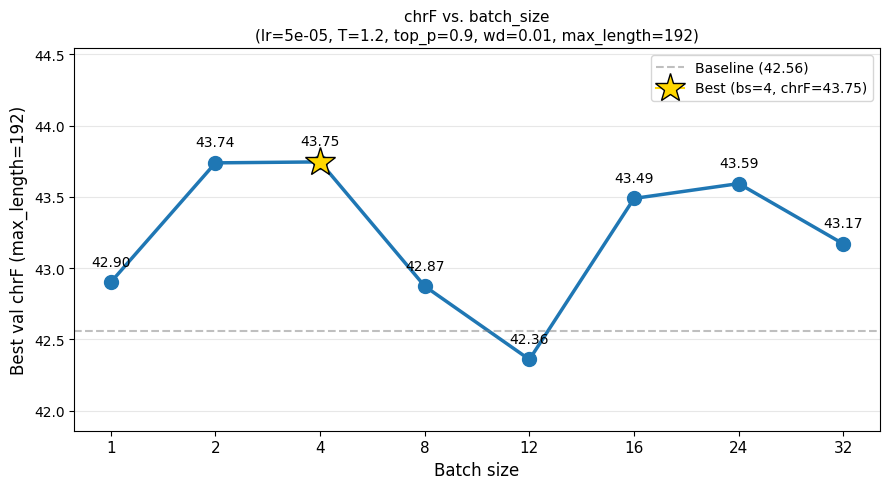

In [9]:
# === Stage E: batch_size sweep, save ckpts as batch_<bs>.pt ===
from sonnet_generation import SonnetGPT
from sacrebleu.metrics import CHRF
from datasets import SonnetsDataset
import torch, os, datetime, glob, time, shutil

BS_GRID = [1, 2, 4, 8, 12, 16, 24, 32]
print(f'Stage E: {len(BS_GRID)} batch sizes')
print(f'All best params:')
print(f'  lr={BEST_LR}, T={BEST_TEMP}, top_p={BEST_TOP_P}, '
      f'wd={BEST_WD}, max_length={BEST_MAXLEN}\n')

val_prompts = SonnetsDataset('data/sonnets_held_out_dev.txt')
val_refs    = SonnetsDataset('data/TRUE_sonnets_held_out_dev.txt')

MIN_CKPT_BYTES = 100_000_000   # 100 MB

@torch.no_grad()
def eval_at_maxlen(ckpt_path, max_len):
    saved = torch.load(ckpt_path, weights_only=False)
    m = SonnetGPT(saved['args']).to('cuda').eval()
    m.load_state_dict(saved['model'])
    gens, refs = [], []
    torch.manual_seed(BASELINE['seed'])
    for idx in range(len(val_prompts)):
        enc = m.tokenizer(val_prompts[idx][1], return_tensors='pt',
                          padding=False, truncation=True).to('cuda')
        _, txt = m.generate(enc['input_ids'], temperature=BEST_TEMP,
                            top_p=BEST_TOP_P, max_length=max_len)
        gens.append(txt); refs.append(val_refs[idx][1])
    score = float(CHRF().corpus_score(gens, [refs]).score)
    del m, saved; torch.cuda.empty_cache()
    return score

def safe_eval(ckpt_path, max_len, bs):
    if not ckpt_path or not os.path.exists(ckpt_path):
        print(f'  [!!] bs={bs}: ckpt missing')
        return -1.0
    size_mb = os.path.getsize(ckpt_path) / 1e6
    if size_mb < MIN_CKPT_BYTES / 1e6:
        print(f'  [!!] bs={bs}: ckpt too small ({size_mb:.1f} MB)')
        return -1.0
    try:
        return eval_at_maxlen(ckpt_path, max_len)
    except Exception as e:
        print(f'  [!!] bs={bs}: load failed: {e}')
        return -1.0

results_e = []
for bs in BS_GRID:
    name = f'E_bs{bs}'
    ts = datetime.datetime.now().strftime('%H%M%S')
    log_file = f'{LOG_DIR}/exp_{name}_{ts}.log'
    local_ckpt = f'batch_{bs}.pt'                # final local name
    drive_ckpt = f'{CKPT_DIR}/batch_{bs}.pt'     # final Drive name
    print(f'\n{"="*60}\n{name}  (bs={bs})  ->  {local_ckpt}\n{"="*60}')

    # Clean stale files BEFORE training
    !rm -f best_*.pt
    !rm -f batch_{bs}.pt

    # Record time before training; used to identify newly-written ckpt
    t_before = time.time()

    # Train
    !python -u sonnet_generation.py \
        --use_gpu --model_size gpt2 \
        --epochs {BASELINE['epochs']} \
        --lr {BEST_LR} \
        --batch_size {bs} \
        --patience {BASELINE['patience']} \
        --temperature {BEST_TEMP} \
        --top_p {BEST_TOP_P} \
        --weight_decay {BEST_WD} \
        --sonnet_out predictions/sonnets_{name}.txt 2>&1 \
        | grep -E "Epoch|train loss|val loss|save the model|train-|patience|Early" \
        | tee {log_file}

    # Find the freshly-written ckpt (any best_*.pt created after t_before, > 100MB)
    time.sleep(1)   # let filesystem settle
    candidates = []
    for f in glob.glob('best_*.pt'):
        if os.path.getmtime(f) >= t_before and os.path.getsize(f) >= MIN_CKPT_BYTES:
            candidates.append(f)

    if candidates:
        # Take the newest one
        candidates.sort(key=os.path.getmtime, reverse=True)
        produced = candidates[0]
        # Rename to batch_<bs>.pt (atomic)
        shutil.move(produced, local_ckpt)
        size_mb = os.path.getsize(local_ckpt) / 1e6
        print(f'  Renamed {produced} -> {local_ckpt}  ({size_mb:.1f} MB)')

        # Backup to Drive
        shutil.copy(local_ckpt, drive_ckpt)
        print(f'  Backed up -> {drive_ckpt}')

        # Clean up any leftover best_*.pt files in cwd
        !rm -f best_*.pt
    else:
        print(f'  [!!] No fresh ckpt found after training!')
        local_ckpt = None

    _, ep = parse_log_chrf(log_file)

    # Evaluate with BEST_MAXLEN
    chrf = safe_eval(local_ckpt, BEST_MAXLEN, bs)

    results_e.append({
        'batch_size': bs,
        'best_chrF':  chrf,
        'best_epoch': ep,
        'log':  log_file,
        'ckpt': drive_ckpt if local_ckpt else None,
    })
    print(f'-> bs={bs}: chrF@{BEST_MAXLEN}={chrf:.2f} (ep {ep})')

results_e.sort(key=lambda r: r['batch_size'])

# Pick best from valid results
valid = [r for r in results_e if r['best_chrF'] > 0]
best = max(valid, key=lambda r: r['best_chrF']) if valid else results_e[0]
save_stage_result('stageE_bs_plot', results_e, best)


# === Plot - x-axis evenly spaced, ASCII only ===
import matplotlib.pyplot as plt
import numpy as np

plot_data = [(r['batch_size'], r['best_chrF']) for r in results_e if r['best_chrF'] > 0]
if not plot_data:
    print('\n[!!] No valid results to plot.')
else:
    bss   = [p[0] for p in plot_data]
    chrfs = [p[1] for p in plot_data]
    x_pos = np.arange(len(bss))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(x_pos, chrfs, marker='o', linewidth=2.5, markersize=10, color='#1f77b4')
    for x, y in zip(x_pos, chrfs):
        ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points',
                    xytext=(0, 12), ha='center', fontsize=10)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(b) for b in bss], fontsize=11)
    ax.set_xlabel('Batch size', fontsize=12)
    ax.set_ylabel(f'Best val chrF (max_length={BEST_MAXLEN})', fontsize=12)
    ax.set_title(f'chrF vs. batch_size\n'
                 f'(lr={BEST_LR}, T={BEST_TEMP}, top_p={BEST_TOP_P}, '
                 f'wd={BEST_WD}, max_length={BEST_MAXLEN})', fontsize=11)
    ax.grid(alpha=0.3, axis='y')
    ax.axhline(BASELINE_CHRF, ls='--', color='gray', alpha=0.5,
               label=f'Baseline ({BASELINE_CHRF})')

    # best_idx = int(np.argmax(chrfs))
    # ax.plot(x_pos[best_idx], chrfs[best_idx], marker='*',
    #         markersize=22, color='gold', markeredgecolor='black',
    #         zorder=5, label=f'Best (bs={bss[best_idx]}, chrF={chrfs[best_idx]:.2f})')

    ax.legend(loc='best', fontsize=10)
    ymin = min(min(chrfs), BASELINE_CHRF) - 0.5
    ymax = max(chrfs) + 0.8
    ax.set_ylim(ymin, ymax)
    plt.tight_layout()

    plot_path = f'{RESULTS_DIR}/stageE_bs_plot.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f'\nPlot saved -> {plot_path}')
    plt.show()

### 10. Generate final submission

Uses **Stage D's best checkpoint** and the winning `(T, top_p, max_length)`. The submission
script's default `max_length` is 128 — if `BEST_MAXLEN != 128`, this cell re-generates
with the right value.

In [ ]:
# === Final submission ===
from sonnet_generation import SonnetGPT
from datasets import SonnetsDataset

# Restore final ckpt locally
local_ckpt = 'best_FINAL.pt'
if not os.path.exists(local_ckpt):
    shutil.copy(BEST_FINAL_CKPT, local_ckpt)
print(f'Loading FINAL ckpt: {BEST_FINAL_CKPT}')

saved = torch.load(local_ckpt, weights_only=False)
model = SonnetGPT(saved['args']).to('cuda').eval()
model.load_state_dict(saved['model'])

held_out = SonnetsDataset('data/sonnets_held_out.txt')

out_path = f'{RESULTS_DIR}/generated_sonnets_FINAL.txt'
print(f'Generating to: {out_path}')
print(f'Using: T={BEST_TEMP}, top_p={BEST_TOP_P}, max_length={BEST_MAXLEN}\n')

generated = []
torch.manual_seed(BASELINE['seed'])
for entry in held_out:
    sonnet_id, prompt = entry[0], entry[1]
    enc = model.tokenizer(prompt, return_tensors='pt',
                          padding=False, truncation=True).to('cuda')
    out_ids, _ = model.generate(enc['input_ids'],
                                temperature=BEST_TEMP,
                                top_p=BEST_TOP_P,
                                max_length=BEST_MAXLEN)
    decoded = model.tokenizer.decode(out_ids[0])
    generated.append((sonnet_id, decoded + '\n\n'))

with open(out_path, 'w') as f:
    f.write('--Generated Sonnets-- \n\n')
    for sid, text in generated:
        f.write(f'\n{sid}\n{text}')

# Also copy to predictions/ for the grader
shutil.copy(out_path, 'predictions/generated_sonnets_FINAL.txt')
print(f'Done. Saved {len(generated)} sonnets.')
print(f'  Drive copy:  {out_path}')
print(f'  Local copy:  predictions/generated_sonnets_FINAL.txt')


# Sonnet Generation

## **baseline**

| Metric | Value |
| ------ | ----- |
| epochs | `20` |
| lr | `1e-5` |
| batch_size | `8` |
| patience | `5` |
| temperature | `1.2` |
| top_p | `0.9` |
| max_length | `128` |
| best dev chrF | `42.39` |

## 1. temperature + top_p

Stage A: 16 configs (all other params use baseline).

| temperature | top_p | chrF |
| ----------- | ----- | ---- |
| `1.00` | `0.85` | `42.11` |
| `1.00` | `0.90` | `42.18` |
| `1.00` | `0.95` | `42.35` |
| `1.10` | `0.85` | `41.84` |
| `1.10` | `0.90` | `41.58` |
| `1.10` | `0.95` | `41.60` |
| `1.20` | `0.85` | `41.86` |
| `1.20` | `0.90` | `42.16` |
| `1.20` | `0.95` | `40.84` |
| `1.30` | `0.85` | `41.28` |
| `1.30` | `0.90` | `41.98` |
| `1.30` | `0.95` | `41.27` |
| `1.00` | `0.70` | `41.48` |
| `1.10` | `0.70` | `41.84` |
| `1.20` | `0.70` | `42.32` |
| `1.30` | `0.70` | `42.49` |

**Stage A winner:** `T=1.3`, `top_p=0.7` (chrF `42.49`)

## 2. learning_rate

Stage B: use Stage A best `T` and `top_p`; other params use baseline.

| lr | temperature | top_p | best chrF | best epoch |
| -- | ----------- | ----- | --------- | ---------- |
| `5e-6` | `1.3` | `0.7` | `41.40` | `2` |
| `1e-5` | `1.3` | `0.7` | `42.56` | `9` |
| `2e-5` | `1.3` | `0.7` | `42.36` | `9` |
| `3e-5` | `1.3` | `0.7` | `42.54` | `8` |
| `4e-5` | `1.3` | `0.7` | `42.68` | `2` |
| `5e-5` | `1.3` | `0.7` | `42.73` | `6` |

**Stage B winner:** `lr=5e-5` (chrF `42.73`)

## 3. max_length

Stage C: use Stage A best `T`, `top_p` and Stage B best `lr`; other params use baseline.

| max_length | temperature | top_p | lr | chrF |
| ---------- | ----------- | ----- | -- | ---- |
| `96` | `1.3` | `0.7` | `5e-5` | `40.13` |
| `128` | `1.3` | `0.7` | `5e-5` | `42.02` |
| `160` | `1.3` | `0.7` | `5e-5` | `43.19` |
| `192` | `1.3` | `0.7` | `5e-5` | `43.36` |
| `224` | `1.3` | `0.7` | `5e-5` | `43.10` |
| `256` | `1.3` | `0.7` | `5e-5` | `42.83` |

**Stage C winner:** `max_length=192` (chrF `43.36`)

## 4. weight_decay

Stage D: use Stage A best `T`, `top_p` and Stage B best `lr`; other params use baseline. Special case: `max_length` stays `128` (not Stage C winner).

| weight_decay | temperature | top_p | lr | max_length | best chrF | best epoch |
| ------------ | ----------- | ----- | -- | ---------- | --------- | ---------- |
| `0.01` | `1.3` | `0.7` | `5e-5` | `128` | `42.77` | `6` |
| `0.0` | `1.3` | `0.7` | `5e-5` | `128` | `42.73` | `6` |
| `0.001` | `1.3` | `0.7` | `5e-5` | `128` | `42.63` | `6` |
| `0.1` | `1.3` | `0.7` | `5e-5` | `128` | `42.54` | `6` |
| `0.05` | `1.3` | `0.7` | `5e-5` | `128` | `42.47` | `8` |

**Stage D winner:** `weight_decay=0.01` (chrF `42.77`)

## **summary**

- Best params: `T=1.3`, `top_p=0.7`, `lr=5e-5`, `max_length=192`, `weight_decay=0.01`.